# Notebook 08: Feature Importance
## Weather Trend Forecasting — PM Accelerator Assessment
### Goal: Identify which weather features most influence temperature using Random Forest, XGBoost, Permutation Importance and SHAP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

PROCESSED_DATA = Path('../data/processed/weather_cleaned.csv')
FIGURES_DIR    = Path('../outputs/figures')
MODELS_DIR     = Path('../outputs/models')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA, parse_dates=['last_updated'])
print(f"Loaded: {df.shape}")

Loaded: (144822, 39)


## 1. Prepare Features

In [2]:
# Add time features if not present
if 'day_of_year' not in df.columns:
    df['day_of_year'] = df['last_updated'].dt.dayofyear
if 'hour' not in df.columns:
    df['hour'] = df['last_updated'].dt.hour
if 'month' not in df.columns:
    df['month'] = df['last_updated'].dt.month

# Select features for predicting temperature
feature_cols = [
    'humidity', 'pressure_mb', 'wind_kph', 'precip_mm',
    'visibility_km', 'uv_index', 'cloud', 'gust_kph',
    'feels_like_celsius', 'air_quality_PM2.5', 'air_quality_PM10',
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'month', 'day_of_year', 'hour'
]

target = 'temperature_celsius'

# Sample for speed
df_sample = df[feature_cols + [target]].dropna().sample(30000, random_state=42)

X = df_sample[feature_cols]
y = df_sample[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Features prepared")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Features: {feature_cols}")

Features prepared
Train: (24000, 18) | Test: (6000, 18)
Features: ['humidity', 'pressure_mb', 'wind_kph', 'precip_mm', 'visibility_km', 'uv_index', 'cloud', 'gust_kph', 'feels_like_celsius', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'month', 'day_of_year', 'hour']


## 2. Random Forest Feature Importance

Training Random Forest...
 Random Forest R²: 0.9971


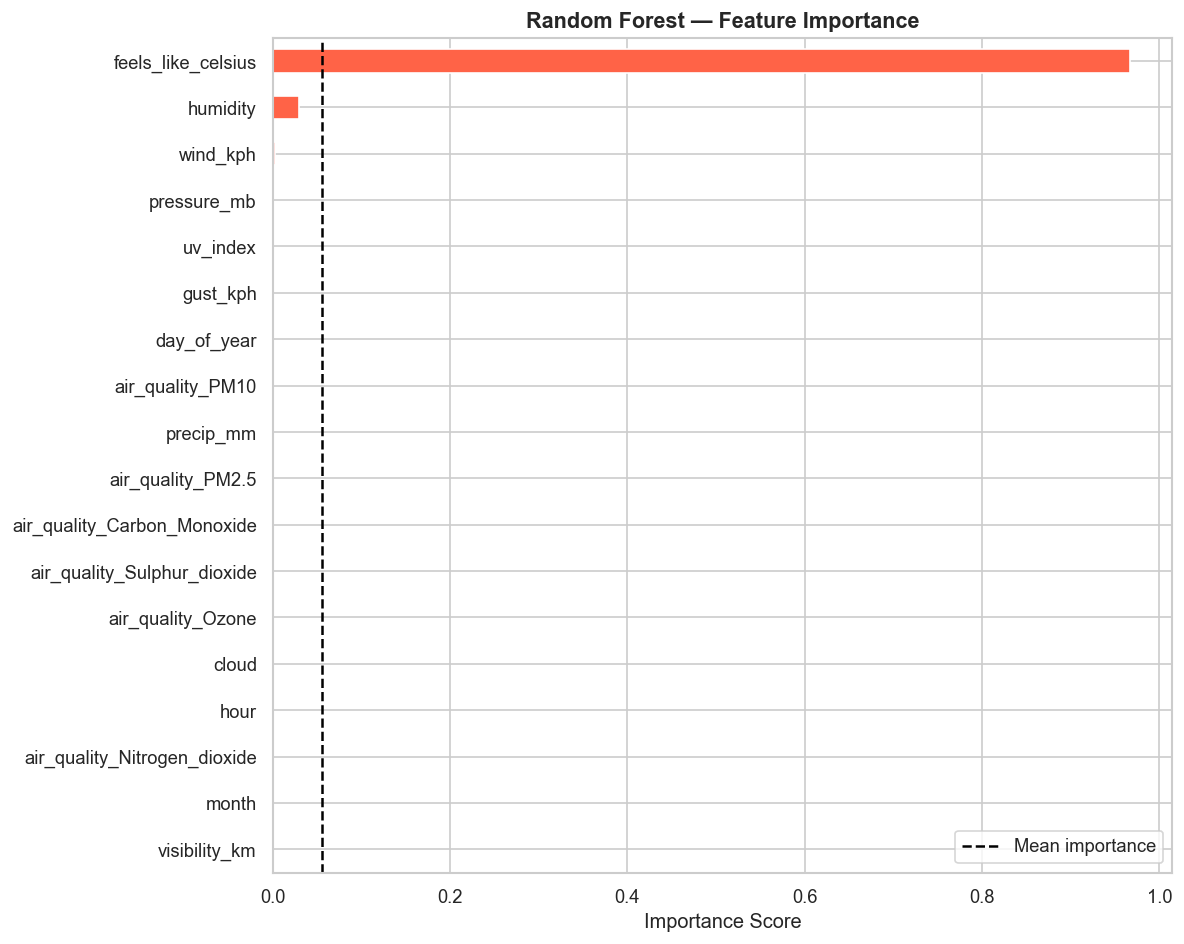

 Saved: 39_rf_feature_importance.png


In [3]:
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_score = rf_model.score(X_test, y_test)
print(f" Random Forest R²: {rf_score:.4f}")

# Feature importance
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if v > rf_importance.quantile(0.75)
          else 'steelblue' for v in rf_importance.values]
rf_importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Random Forest — Feature Importance',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.axvline(rf_importance.mean(), color='black',
           linestyle='--', linewidth=1.5, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '39_rf_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 39_rf_feature_importance.png")

## 3. XGBoost Feature Importance

Training XGBoost...
 XGBoost R²: 0.9978


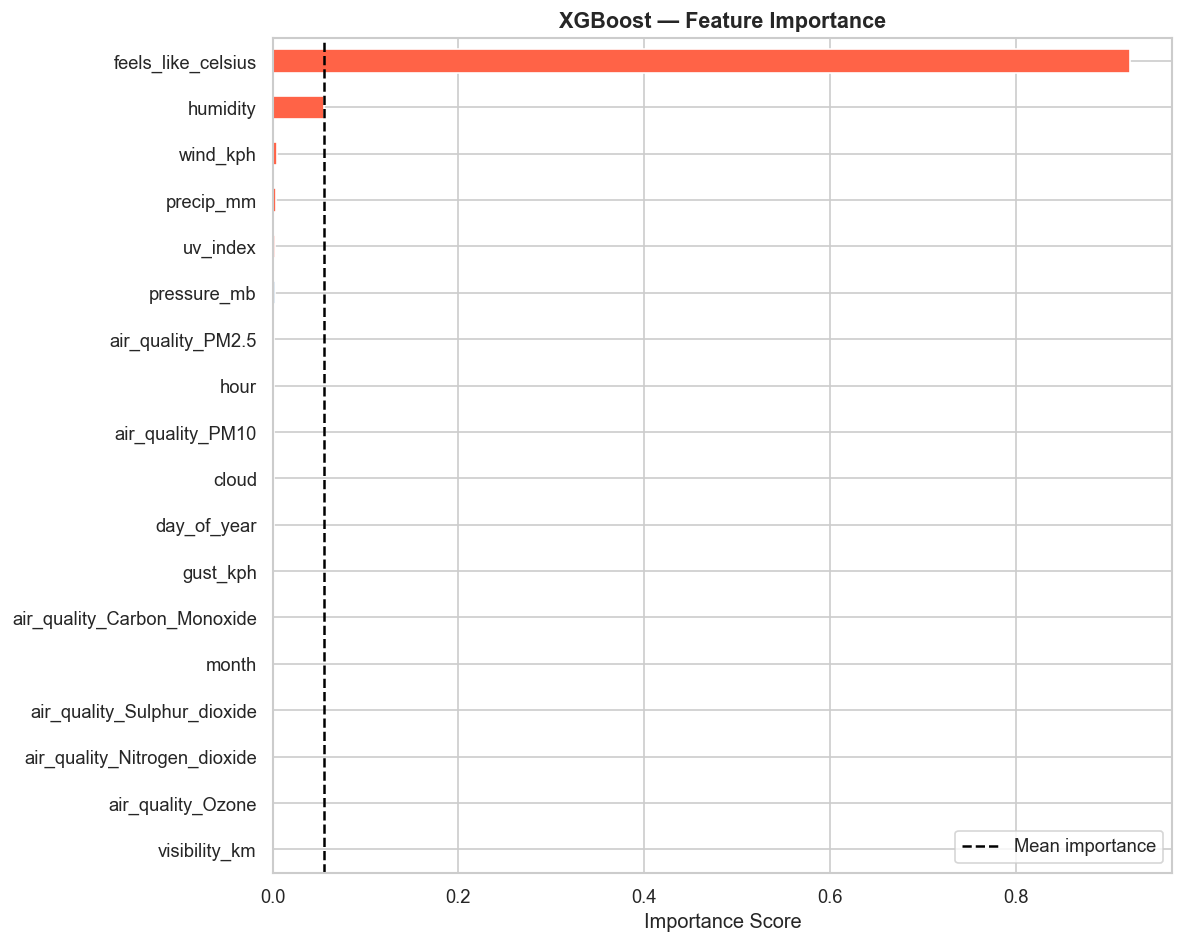

 Saved: 40_xgb_feature_importance.png


In [4]:
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_score = xgb_model.score(X_test, y_test)
print(f" XGBoost R²: {xgb_score:.4f}")

# XGBoost importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if v > xgb_importance.quantile(0.75)
          else 'steelblue' for v in xgb_importance.values]
xgb_importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('XGBoost — Feature Importance',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.axvline(xgb_importance.mean(), color='black',
           linestyle='--', linewidth=1.5, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '40_xgb_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 40_xgb_feature_importance.png")

## 4. SHAP Values (XGBoost)

Computing SHAP values (this may take ~1 min)...
SHAP values computed


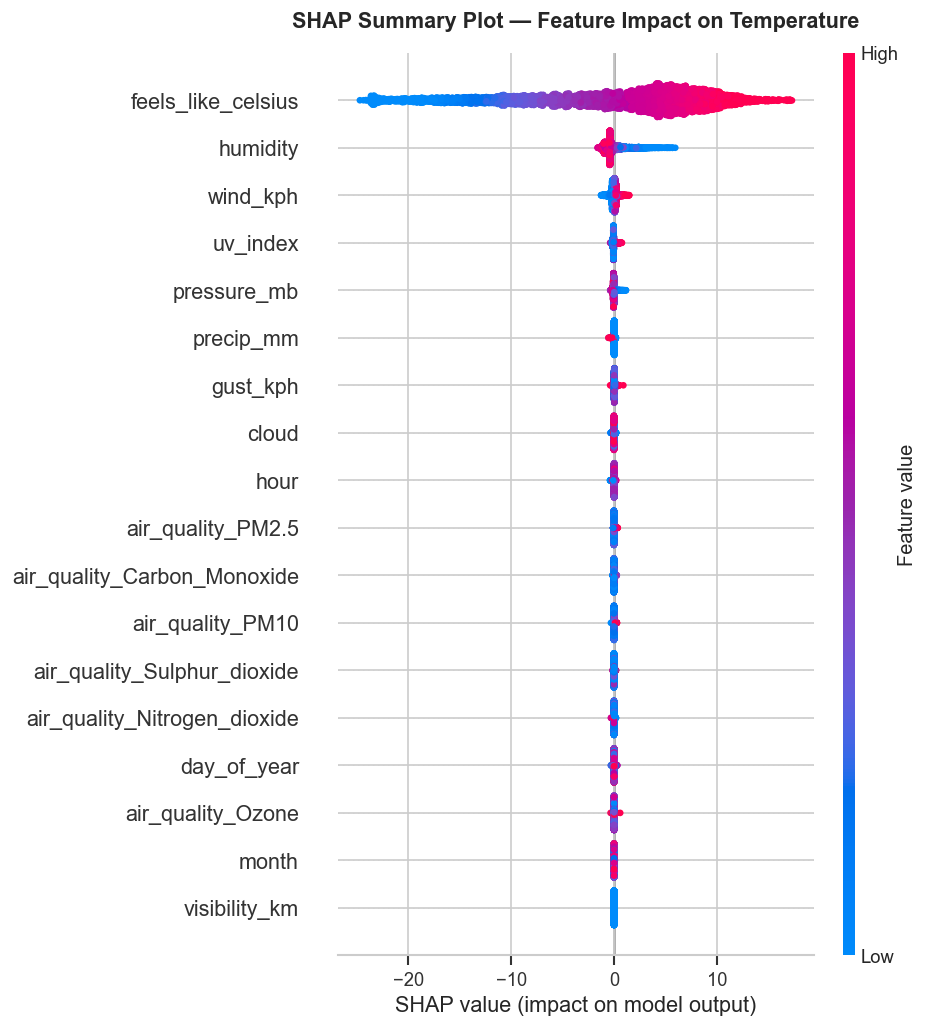

Saved: 41_shap_summary.png


In [5]:
print("Computing SHAP values (this may take ~1 min)...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print("SHAP values computed")

# SHAP Summary Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  show=False)
plt.title('SHAP Summary Plot — Feature Impact on Temperature',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '41_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 41_shap_summary.png")

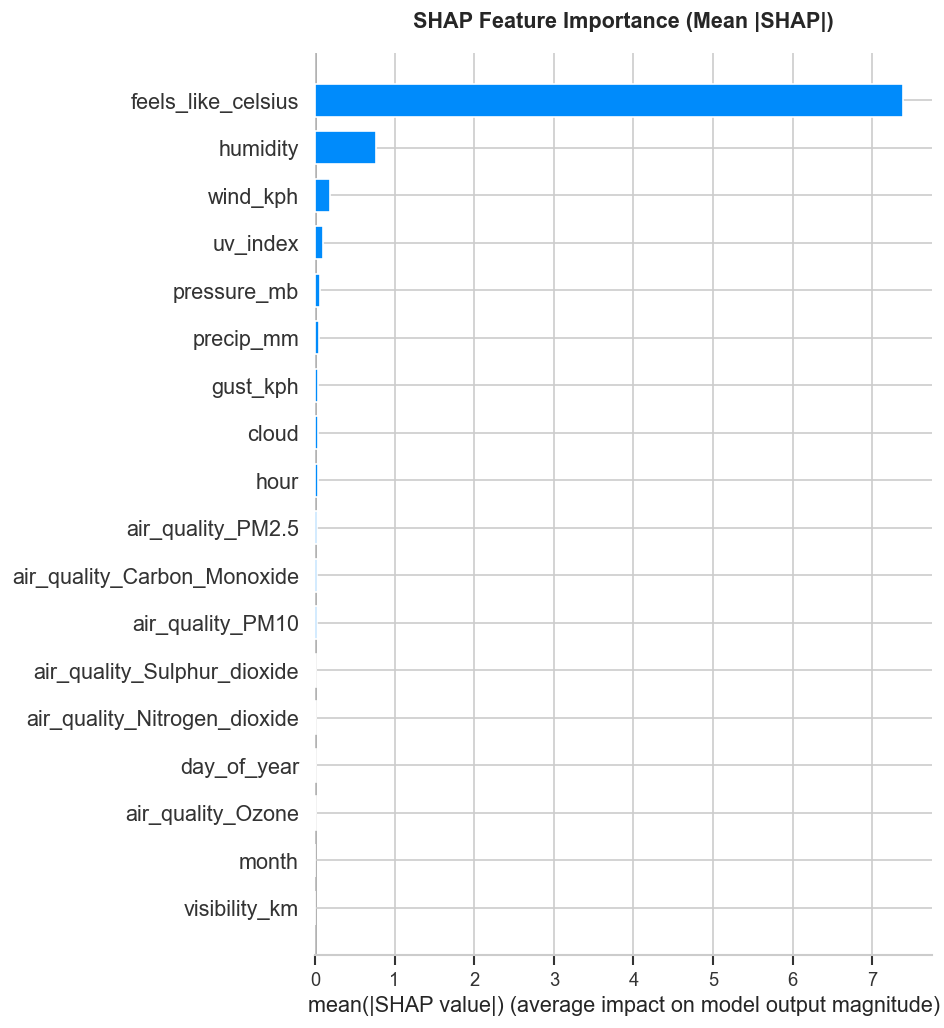

 Saved: 42_shap_bar.png


In [6]:
# SHAP Bar Plot — mean absolute SHAP values
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '42_shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 42_shap_bar.png")

## 5. Permutation Importance

Computing permutation importance...


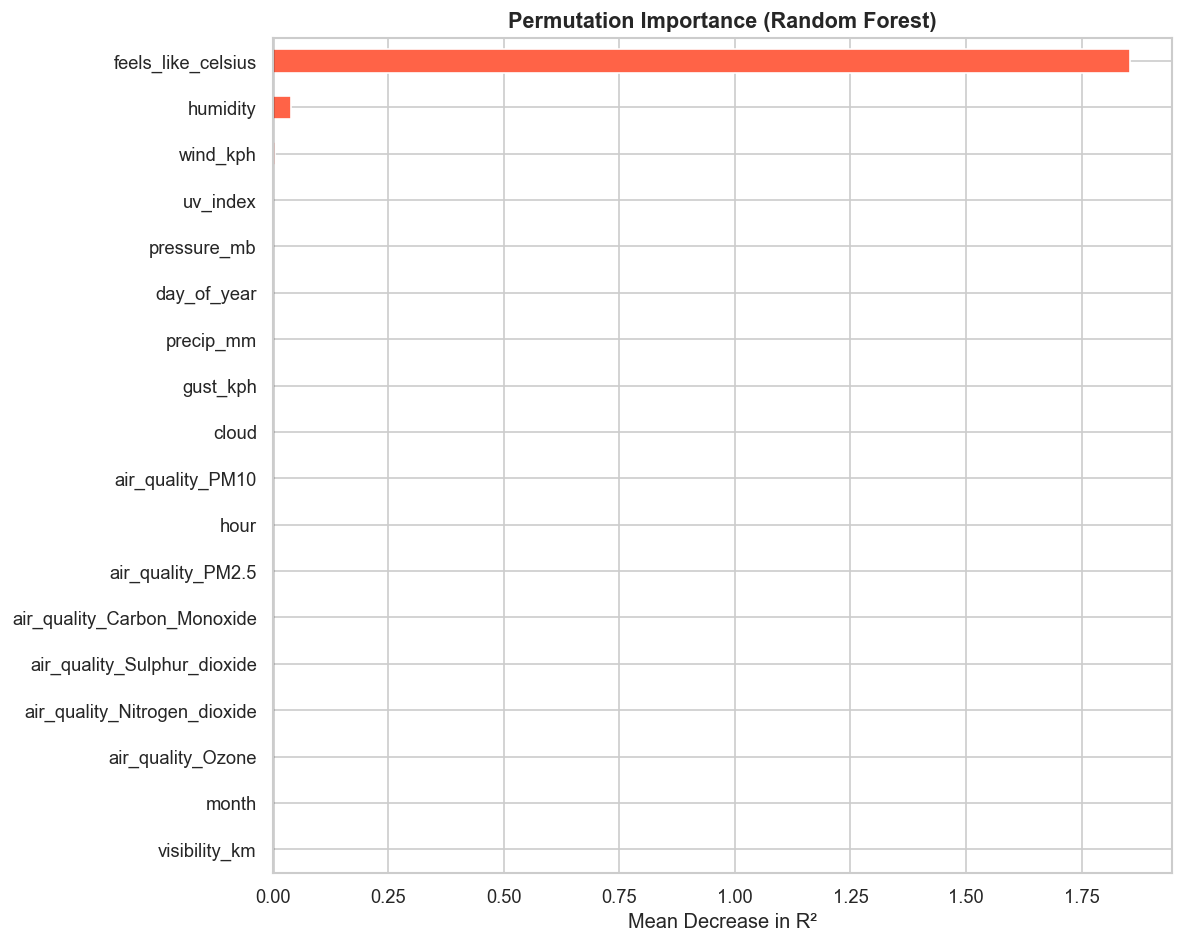

 Saved: 43_permutation_importance.png


In [7]:
print("Computing permutation importance...")
perm_result = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance = pd.Series(
    perm_result.importances_mean,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if v > perm_importance.quantile(0.75)
          else 'steelblue' for v in perm_importance.values]
perm_importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Permutation Importance (Random Forest)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Mean Decrease in R²')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '43_permutation_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 43_permutation_importance.png")

## 6. Feature Importance Comparison

Feature Importance Comparison (normalized 0-1):
                              Random Forest  XGBoost  Permutation   SHAP
feels_like_celsius                    1.000    1.000        1.000  1.000
humidity                              0.031    0.060        0.022  0.104
wind_kph                              0.002    0.005        0.002  0.025
uv_index                              0.000    0.003        0.000  0.014
pressure_mb                           0.000    0.002        0.000  0.009
precip_mm                             0.000    0.003        0.000  0.007
gust_kph                              0.000    0.001        0.000  0.006
cloud                                 0.000    0.001        0.000  0.005
hour                                  0.000    0.002        0.000  0.005
air_quality_PM2.5                     0.000    0.002        0.000  0.004
air_quality_Carbon_Monoxide           0.000    0.001        0.000  0.004
air_quality_PM10                      0.000    0.001        0.000  0.003
air

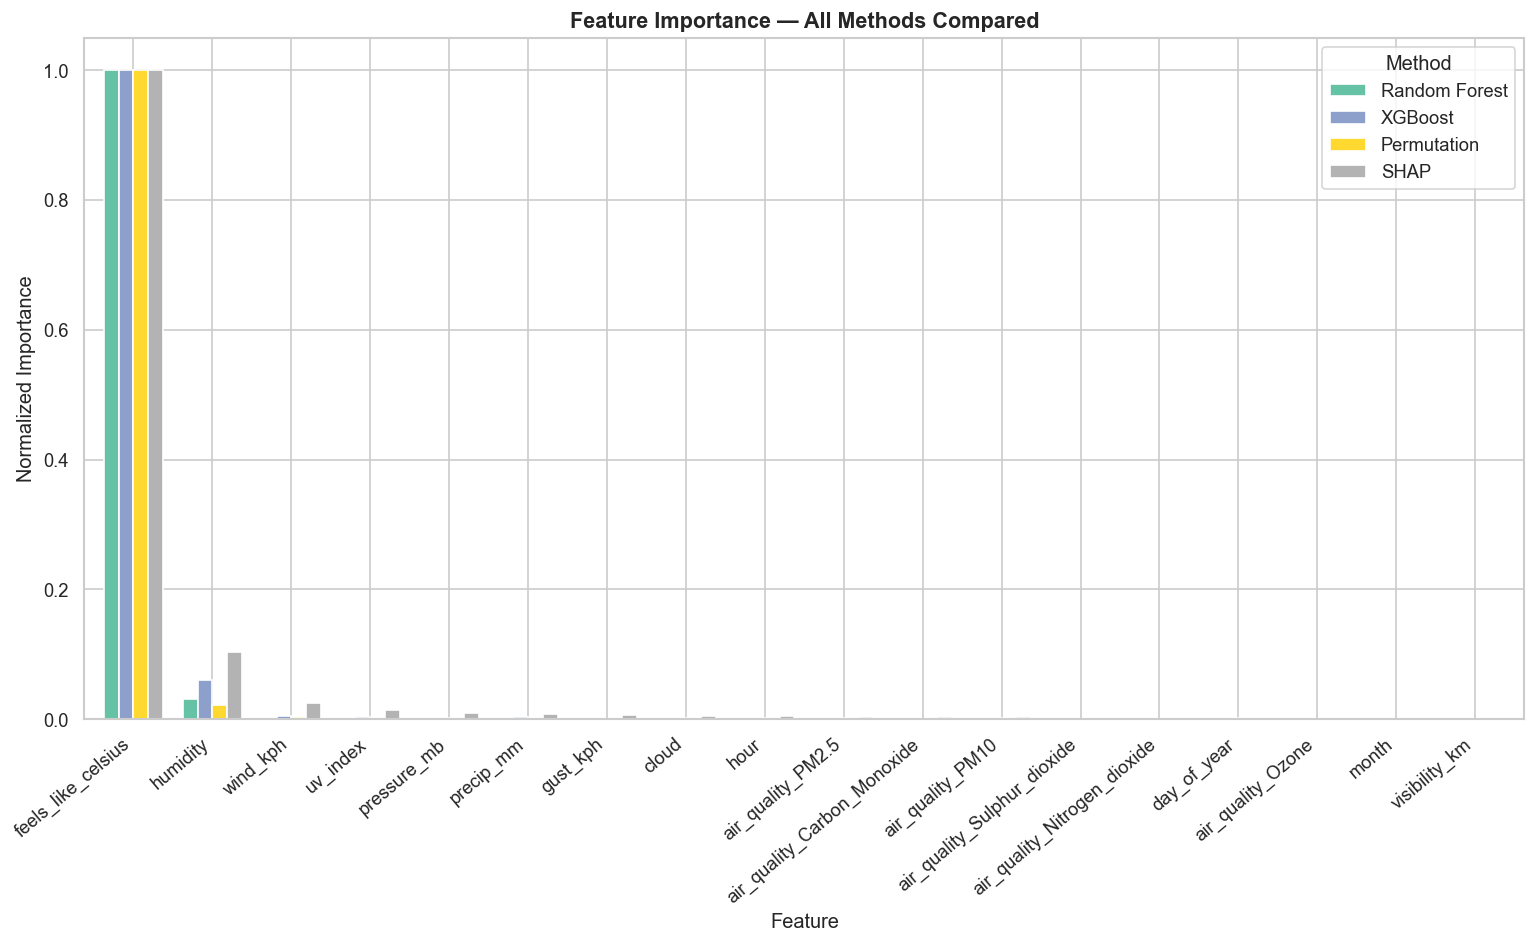

 Saved: 44_importance_comparison.png


In [ ]:
# Normalize all importance scores to 0-1 for comparison
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

comparison_df = pd.DataFrame({
    'Random Forest':    normalize(pd.Series(rf_model.feature_importances_,
                                            index=feature_cols)),
    'XGBoost':          normalize(pd.Series(xgb_model.feature_importances_,
                                            index=feature_cols)),
    'Permutation':      normalize(pd.Series(perm_result.importances_mean,
                                            index=feature_cols)),
    'SHAP':             normalize(pd.Series(np.abs(shap_values).mean(axis=0),
                                            index=feature_cols))
}).sort_values('SHAP', ascending=False)

print("Feature Importance Comparison (normalized 0-1):")
print(comparison_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(13, 8))
comparison_df.plot(kind='bar', ax=ax, edgecolor='white',
                   colormap='Set2', width=0.75)
ax.set_title('Feature Importance — All Methods Compared',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Normalized Importance')
ax.legend(title='Method')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '44_importance_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 44_importance_comparison.png")